In [1]:
!pip install qrcode pillow

mambajs 0.19.13

Process pip requirements ...

Requirement pillow already handled by conda/micromamba/mamba.


✅ Aesthetic Matrix Compiled & Logo Injected!


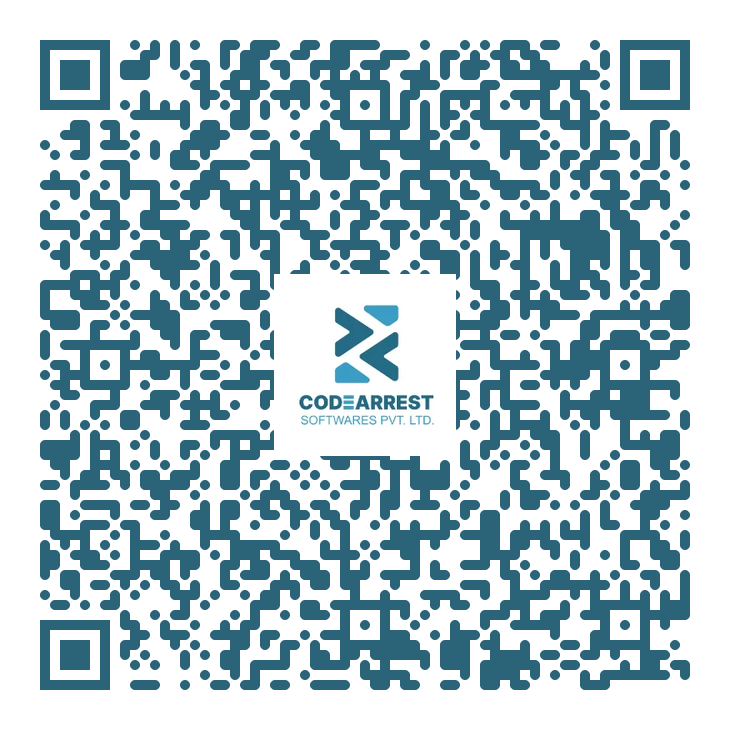

In [12]:
import qrcode
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers.pil import RoundedModuleDrawer
from qrcode.image.styles.colormasks import SolidFillColorMask
from PIL import Image
from IPython.display import display

# 1. THE PAYLOAD (CodeArrest vCard)
vcard_data = """BEGIN:VCARD
VERSION:3.0
ORG:CodeArrest Softwares PVT LTD;
EMAIL:sales@codearrest.com
URL:https://codearrest.com/
TEL:+917073899493
END:VCARD"""

# 2. THE MATRIX BUILDER (High Error Correction)
qr = qrcode.QRCode(
    version=5, 
    error_correction=qrcode.constants.ERROR_CORRECT_H, 
    box_size=10,
    border=4,
)
qr.add_data(vcard_data)
qr.make(fit=True)

# 3. THE AESTHETIC RENDERER (Rounded Dots + Corporate Colors)
# We convert the hex #2B6379 to RGB: (43, 99, 121)
img_qr = qr.make_image(
    image_factory=StyledPilImage,
    module_drawer=RoundedModuleDrawer(radius_ratio=1), # Max roundness for a soft/bubble look
    color_mask=SolidFillColorMask(front_color=(43, 99, 121), back_color=(255, 255, 255))
).convert('RGB')

# 4. BRANDING INJECTION (The Logo)
try:
    logo = Image.open("codearrest_logo.png") # Ensure this is your PNG file!
    
    qr_width, qr_height = img_qr.size
    logo_size = int(qr_width / 4)
    logo = logo.resize((logo_size, logo_size), Image.Resampling.LANCZOS)
    
    pos = ((qr_width - logo_size) // 2, (qr_height - logo_size) // 2)
    img_qr.paste(logo, pos)
    print("✅ Aesthetic Matrix Compiled & Logo Injected!")

except FileNotFoundError:
    print("⚠️ Warning: 'codearrest_logo.png' not found.")

# 5. EXPORT AND DISPLAY
img_qr.save("CodeArrest_Aesthetic_QR.png")
display(img_qr)